# Недообучение и переобучение

#### 1. Загрузите первые 400 строк прилагающегося датасета diabetes.csv.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

df = pd.read_csv("data/diabetes.csv", nrows=400)
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

400 rows, 9 columns


#### 2. Сделайте количественное описание датасета: число признаков, статистику по признакам.

In [39]:
print("Shape:", df.shape)
print("\nStatistics:\n", df.describe())

Shape: (400, 9)

Statistics:
        Pregnancies    Glucose  BloodPressure  SkinThickness     Insulin  \
count   400.000000  400.00000     400.000000     400.000000  400.000000   
mean      3.952500  121.24000      69.060000      20.327500   81.250000   
std       3.369514   32.68437      19.011575      15.599796  121.597254   
min       0.000000    0.00000       0.000000       0.000000    0.000000   
25%       1.000000  100.00000      64.000000       0.000000    0.000000   
50%       3.000000  116.50000      71.000000      23.000000   36.000000   
75%       6.000000  143.00000      80.000000      32.000000  128.250000   
max      17.000000  197.00000     122.000000      60.000000  846.000000   

             BMI  DiabetesPedigreeFunction         Age     Outcome  
count  400.00000                400.000000  400.000000  400.000000  
mean    32.10775                  0.487915   33.092500    0.380000  
std      8.13714                  0.349619   11.325396    0.485994  
min      0.00000  

#### 3. Отделите целевую переменную Outcome.

In [40]:
y = df["Outcome"]
X = df.drop("Outcome", axis=1)
print("Целевая переменная (Outcome):")
print(y.head())
print("\nРаспределение классов Outcome:")
print(y.value_counts())

Целевая переменная (Outcome):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

Распределение классов Outcome:
Outcome
0    248
1    152
Name: count, dtype: int64


#### 4. Разделите данные на обучающую и валидационную выборки при помощи train_test_split из библиотеки sklearn.model_selection в соотношении 80-20 (для этого укажите параметр test_size=0.2) с перемешиванием, указав значение параметра random_state=42.

In [41]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 5. Создайте объект DecisionTreeClassifier(random_state=1). Обучите модель на обучающих (трейновых) данных. Сделайте предсказание на трейновом и валидационном наборе признаков. Выведите значения метрики f1-scoreдля трейнового и валидационного наборов данных. По полученным значениям метрик сделайте предположение о переобученности модели.

In [42]:
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

f1_train = f1_score(y_train, y_train_pred)
f1_val = f1_score(y_val, y_val_pred)
print("Train F1:", f1_train)
print("Validation F1:", f1_val)

Train F1: 1.0
Validation F1: 0.6363636363636364


#### 6. Произведите кросс-валидацию с использованием функции cross_validate из библиотеки sklearn.model_selection. По полученным данным, постройте график зависимости значений f1-score от набора данных соответствующей итерации. По графику убедитесь в том, что имеет место переобученность модели.

Train scores: [1. 1. 1. 1. 1.]
Test scores: [0.49122807 0.61016949 0.65625    0.5        0.45614035]


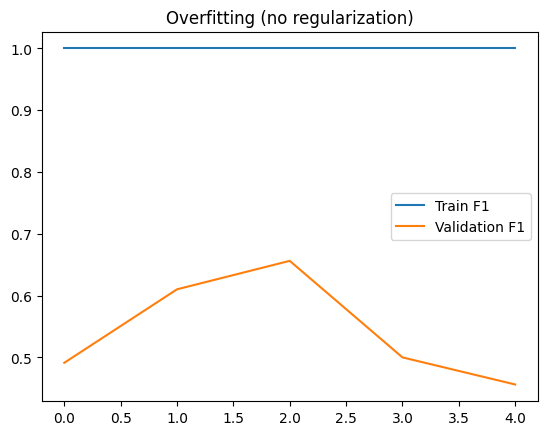

In [43]:
cv_results = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring="f1",
    return_train_score=True
)

train_scores = cv_results["train_score"]
test_scores = cv_results["test_score"]

print("Train scores:", train_scores)
print("Test scores:", test_scores)

plt.plot(train_scores, label="Train F1")
plt.plot(test_scores, label="Validation F1")
plt.legend()
plt.title("Overfitting (no regularization)")
plt.show()

#### 7. Для борьбы с переобучением регуляризуйте модель DecisionTreeClassifier, уменьшив глубину дерева, указав параметр регуляризации max_depth=3.

In [44]:
model_reg = DecisionTreeClassifier(max_depth=3, random_state=1)
model_reg.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

#### 8. Снова проделайте пункт 6 с учётом регуляризации и убелитесь по графику в том, что модель больше не является переобученной.

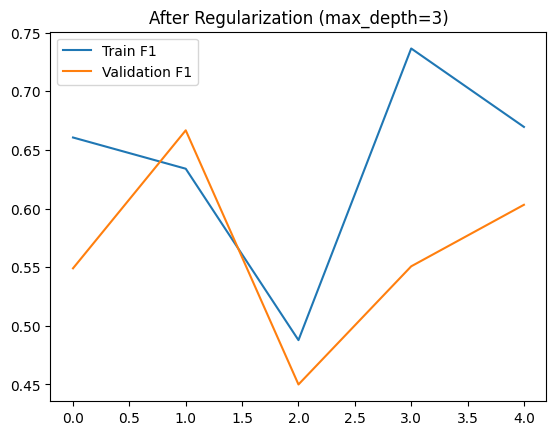

In [45]:
cv_results_reg = cross_validate(
    model_reg,
    X,
    y,
    cv=5,
    scoring="f1",
    return_train_score=True
)

train_scores_reg = cv_results_reg["train_score"]
test_scores_reg = cv_results_reg["test_score"]

plt.plot(train_scores_reg, label="Train F1")
plt.plot(test_scores_reg, label="Validation F1")
plt.legend()
plt.title("After Regularization (max_depth=3)")
plt.show()

#### 9. Теперь рассмотрите проблему недообучения модели. Для борьбы с недообучением модели добавьте данные. Для этого загрузите все строки датасета diabetes.csv.

In [46]:
df_full = pd.read_csv("data/diabetes.csv")

y_full = df_full["Outcome"]
X_full = df_full.drop("Outcome", axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

#### 10. Обучите модель DecisionTreeClassifier(random_state=1, max_depth=3) на всех данных и убедитесь в том, что значение метрики f1-score улучшилось.

In [47]:
model_final = DecisionTreeClassifier(max_depth=3, random_state=1)
model_final.fit(X_train, y_train)

y_pred = model_final.predict(X_val)

print("Final F1:", f1_score(y_val, y_pred))

Final F1: 0.6476190476190476


## Задания для самостоятельного выполнения

#### 1. Повторите диагностику модели классификации синтетических данных с использованием других метрик эффективности - precision, recall, F1. Как изменились результаты?

In [72]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_syn, y_syn = make_classification(
    n_samples=10000,
    n_features=500,
    n_informative=50,
    n_repeated=0,
    class_sep=1,
    random_state=42
)

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.25, random_state=3
)

syn_model = LogisticRegression(max_iter=1000)
syn_model.fit(X_syn_train, y_syn_train)
y_syn_pred = syn_model.predict(X_syn_test)

print(f"Accuracy:  {accuracy_score(y_syn_test, y_syn_pred):.4f}")
print(f"Precision: {precision_score(y_syn_test, y_syn_pred):.4f}")
print(f"Recall:    {recall_score(y_syn_test, y_syn_pred):.4f}")
print(f"F1-score:  {f1_score(y_syn_test, y_syn_pred):.4f}")

Accuracy:  0.8056
Precision: 0.8069
Recall:    0.8056
F1-score:  0.8062


#### 2. Повторите диагностику модели регрессии с использованием других видов моделей:

#### a) метода опорных векторов (исследуйте влияние параметра С на недо-и переобучение)

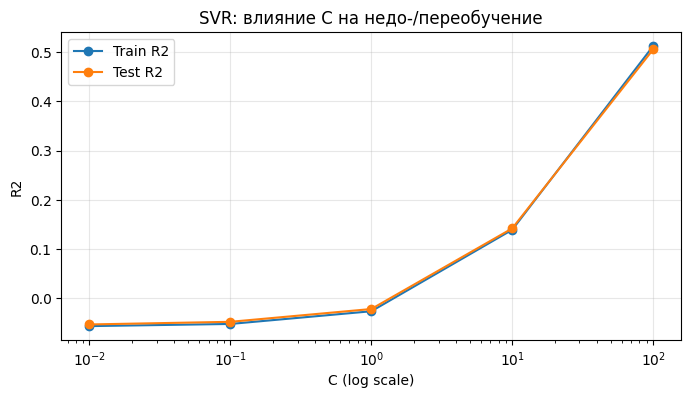

In [73]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_reg2 = housing.data
y_reg2 = housing.target

X_reg2_train, X_reg2_test, y_reg2_train, y_reg2_test = train_test_split(
    X_reg2, y_reg2, test_size=0.25, random_state=42
)

svr_C_values = [0.01, 0.1, 1, 10, 100]
svr_train_r2 = []
svr_test_r2 = []

for c_value in svr_C_values:
    svr_model = SVR(C=c_value)
    svr_model.fit(X_reg2_train, y_reg2_train)
    svr_train_r2.append(r2_score(y_reg2_train, svr_model.predict(X_reg2_train)))
    svr_test_r2.append(r2_score(y_reg2_test, svr_model.predict(X_reg2_test)))

plt.figure(figsize=(8, 4))
plt.plot(svr_C_values, svr_train_r2, marker="o", label="Train R2")
plt.plot(svr_C_values, svr_test_r2, marker="o", label="Test R2")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("R2")
plt.title("SVR: влияние C на недо-/переобучение")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### b) метода ближайших соседей (исследуйте влияние количества соседей)

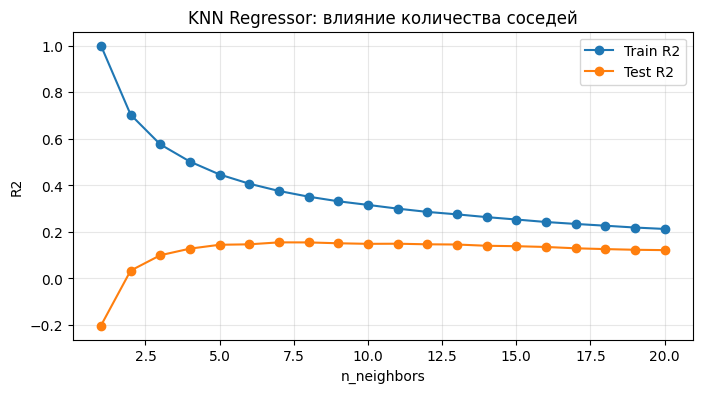

In [74]:
from sklearn.neighbors import KNeighborsRegressor

knn_k_values = range(1, 21)
knn_train_r2 = []
knn_test_r2 = []

for k_value in knn_k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k_value)
    knn_model.fit(X_reg2_train, y_reg2_train)
    knn_train_r2.append(r2_score(y_reg2_train, knn_model.predict(X_reg2_train)))
    knn_test_r2.append(r2_score(y_reg2_test, knn_model.predict(X_reg2_test)))

plt.figure(figsize=(8, 4))
plt.plot(knn_k_values, knn_train_r2, marker="o", label="Train R2")
plt.plot(knn_k_values, knn_test_r2, marker="o", label="Test R2")
plt.xlabel("n_neighbors")
plt.ylabel("R2")
plt.title("KNN Regressor: влияние количества соседей")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### c) метода решающих деревьев (гиперпараметры по вашему выбору)

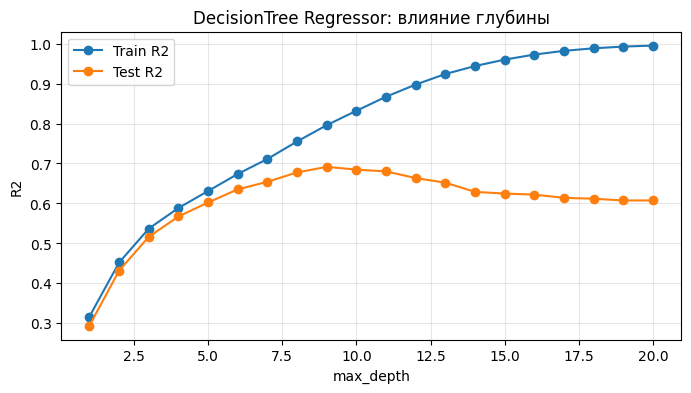

In [75]:
from sklearn.tree import DecisionTreeRegressor

tree_depths = range(1, 21)
tree_train_r2 = []
tree_test_r2 = []

for depth_value in tree_depths:
    tree_model = DecisionTreeRegressor(max_depth=depth_value, random_state=42)
    tree_model.fit(X_reg2_train, y_reg2_train)
    tree_train_r2.append(r2_score(y_reg2_train, tree_model.predict(X_reg2_train)))
    tree_test_r2.append(r2_score(y_reg2_test, tree_model.predict(X_reg2_test)))

plt.figure(figsize=(8, 4))
plt.plot(tree_depths, tree_train_r2, marker="o", label="Train R2")
plt.plot(tree_depths, tree_test_r2, marker="o", label="Test R2")
plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("DecisionTree Regressor: влияние глубины")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### 3. Дополните анализ датасета Бостон исследованием модели лассо - постройте кривые обучения для переобученной, недообученной и качественной модели, найдите оптимальное значение параметра регуляризации в модели лассо.

Boston URL unavailable, fallback: California Housing
Best alpha: 0.01048
Best test R2: 0.5979


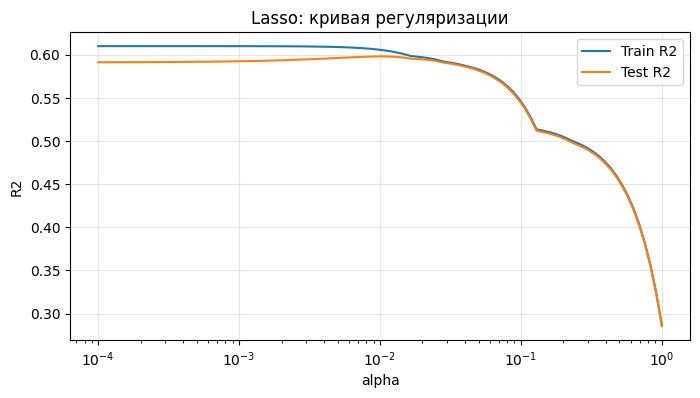

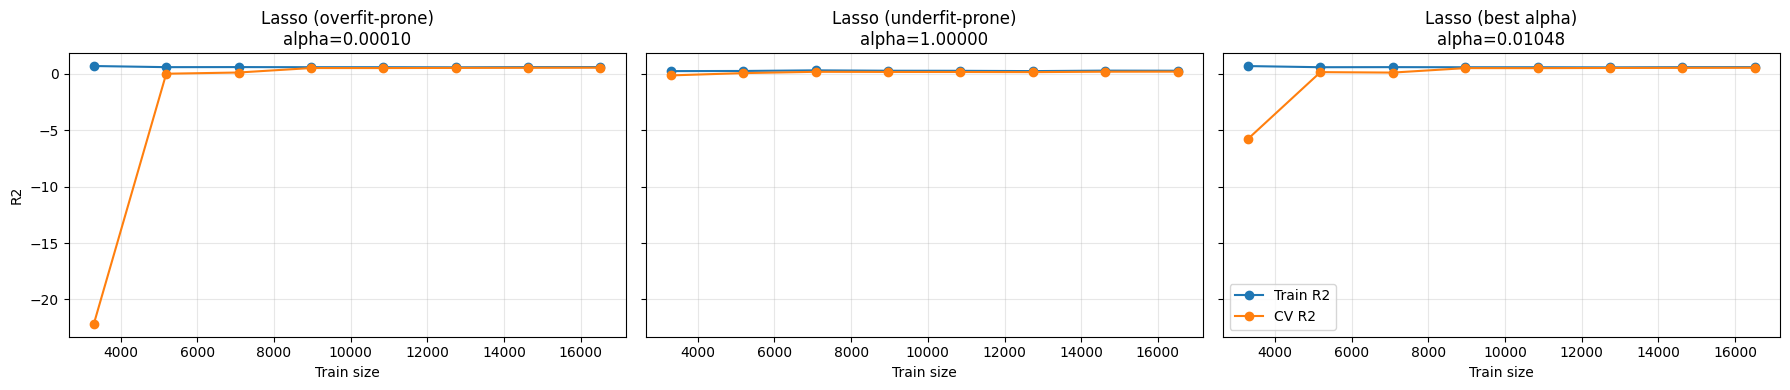

In [ ]:
from numpy import genfromtxt
from sklearn.linear_model import Lasso
from sklearn.model_selection import learning_curve
from sklearn.datasets import fetch_california_housing

try:
    boston_like = genfromtxt(
        "https://raw.githubusercontent.com/m-mehdi/tutorials/main/boston_housing.csv",
        delimiter=",",
    )
    if np.isnan(boston_like).all() or boston_like.ndim != 2 or boston_like.shape[1] < 2:
        raise ValueError("Boston URL unavailable")
    X_lasso = boston_like[:, :-1]
    y_lasso = boston_like[:, -1]
    print("Using Boston-like dataset from URL")
except Exception:
    cali = fetch_california_housing()
    X_lasso = cali.data
    y_lasso = cali.target
    print("Boston URL unavailable, fallback: California Housing")

X_lasso_train, X_lasso_test, y_lasso_train, y_lasso_test = train_test_split(
    X_lasso, y_lasso, test_size=0.25, random_state=42
)

alpha_grid = np.logspace(-4, 0, 100)
train_r2 = []
test_r2 = []

for alpha_value in alpha_grid:
    lasso_model = Lasso(alpha=alpha_value, max_iter=10000)
    lasso_model.fit(X_lasso_train, y_lasso_train)
    train_r2.append(lasso_model.score(X_lasso_train, y_lasso_train))
    test_r2.append(lasso_model.score(X_lasso_test, y_lasso_test))

best_idx = int(np.argmax(test_r2))
best_alpha = alpha_grid[best_idx]
print(f"Best alpha: {best_alpha:.5f}")
print(f"Best test R2: {test_r2[best_idx]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(alpha_grid, train_r2, label="Train R2")
plt.plot(alpha_grid, test_r2, label="Test R2")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R2")
plt.title("Lasso: кривая регуляризации")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

alpha_overfit = alpha_grid[0] # очень слабая регуляризация
alpha_underfit = alpha_grid[-1] # очень сильная регуляризация
alpha_good = best_alpha

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, alpha_value, title in [
    (axes[0], alpha_overfit, "Lasso (overfit-prone)"),
    (axes[1], alpha_underfit, "Lasso (underfit-prone)"),
    (axes[2], alpha_good, "Lasso (best alpha)"),
]:
    sizes, tr_scores, te_scores = learning_curve(
        Lasso(alpha=alpha_value, max_iter=10000),
        X_lasso,
        y_lasso,
        train_sizes=np.linspace(0.2, 1.0, 8),
        cv=5,
        scoring="r2",
        n_jobs=-1,
    )
    ax.plot(sizes, tr_scores.mean(axis=1), marker="o", label="Train R2")
    ax.plot(sizes, te_scores.mean(axis=1), marker="o", label="CV R2")
    ax.set_title(f"{title}\nalpha={alpha_value:.5f}")
    ax.set_xlabel("Train size")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("R2")
axes[2].legend()
plt.tight_layout()
plt.show()

#### 4. В одном из двух первых примеров используйте модель ElasticNet и исследуйте влияние сразу двух параметров регуляризации на эффективность модели.

Best ElasticNet alpha: 0.01931
Best ElasticNet l1_ratio: 0.20
Best validation R2: 0.5980


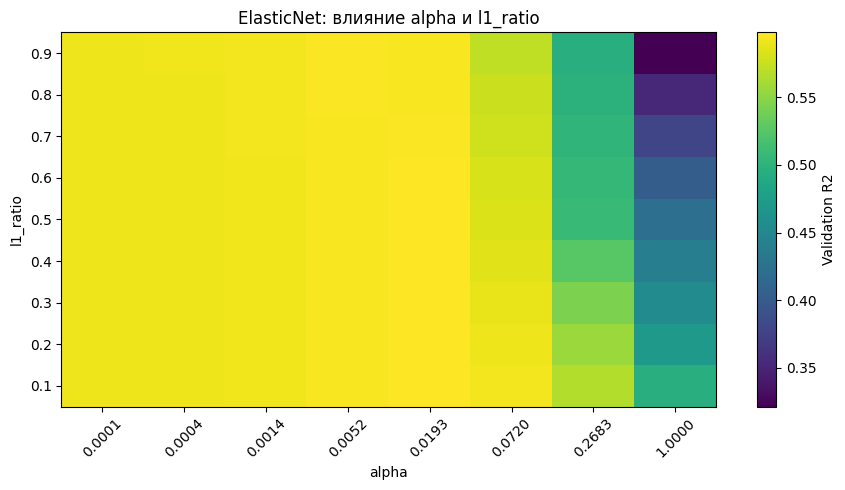

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_en = housing.data
y_en = housing.target
X_en_train, X_en_test, y_en_train, y_en_test = train_test_split(
    X_en, y_en, test_size=0.25, random_state=42
)

en_alphas = np.logspace(-4, 0, 8)
en_l1_ratios = np.linspace(0.1, 0.9, 9)
en_scores = np.zeros((len(en_l1_ratios), len(en_alphas)))

for i, l1_ratio_value in enumerate(en_l1_ratios):
    for j, alpha_value in enumerate(en_alphas):
        en_model = ElasticNet(
            alpha=alpha_value,
            l1_ratio=l1_ratio_value,
            max_iter=10000,
            random_state=42
        )
        en_model.fit(X_en_train, y_en_train)
        en_scores[i, j] = en_model.score(X_en_test, y_en_test)

best_i, best_j = np.unravel_index(np.argmax(en_scores), en_scores.shape)
print(f"Best ElasticNet alpha: {en_alphas[best_j]:.5f}")
print(f"Best ElasticNet l1_ratio: {en_l1_ratios[best_i]:.2f}")
print(f"Best validation R2: {en_scores[best_i, best_j]:.4f}")

plt.figure(figsize=(9, 5))
plt.imshow(en_scores, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="Validation R2")
plt.xticks(range(len(en_alphas)), [f"{a:.4f}" for a in en_alphas], rotation=45)
plt.yticks(range(len(en_l1_ratios)), [f"{r:.1f}" for r in en_l1_ratios])
plt.xlabel("alpha")
plt.ylabel("l1_ratio")
plt.title("ElasticNet: влияние alpha и l1_ratio")
plt.tight_layout()
plt.show()

#### 5. Дополните анализ дерева решений из третьего примера: постройте кривые регуляризации для полного датасета, найдите оптимальную глубину дерева и оцените качество такой модели на всем датасете. Повторите данный анализ используя в качестве метрики эффективности F1.

Best depth by CV F1: 4
Best CV F1: 0.6341


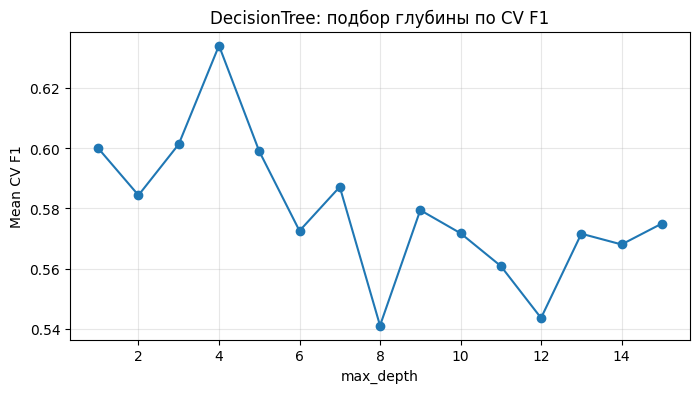

Hold-out F1 (best depth): 0.6931


In [78]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

df_tree_full = pd.read_csv("data/diabetes.csv")
X_tree_full = df_tree_full.drop("Outcome", axis=1)
y_tree_full = df_tree_full["Outcome"]

tree_depth_candidates = range(1, 16)
tree_f1_cv_mean = []

for depth_value in tree_depth_candidates:
    tree_model = DecisionTreeClassifier(max_depth=depth_value, random_state=42)
    f1_scores_cv = cross_val_score(
        tree_model,
        X_tree_full,
        y_tree_full,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="f1"
    )
    tree_f1_cv_mean.append(f1_scores_cv.mean())

best_depth_idx = int(np.argmax(tree_f1_cv_mean))
best_depth = list(tree_depth_candidates)[best_depth_idx]
print(f"Best depth by CV F1: {best_depth}")
print(f"Best CV F1: {tree_f1_cv_mean[best_depth_idx]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(tree_depth_candidates), tree_f1_cv_mean, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Mean CV F1")
plt.title("DecisionTree: подбор глубины по CV F1")
plt.grid(alpha=0.3)
plt.show()

X_tree_train, X_tree_val, y_tree_train, y_tree_val = train_test_split(
    X_tree_full, y_tree_full, test_size=0.2, random_state=42, stratify=y_tree_full
)
best_tree_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_tree_model.fit(X_tree_train, y_tree_train)
y_tree_val_pred = best_tree_model.predict(X_tree_val)
print(f"Hold-out F1 (best depth): {f1_score(y_tree_val, y_tree_val_pred):.4f}")

#### 6. Повторите анализ на других реальных датасетах из репозитория OpenML:

#### phoneme

In [79]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, r2_score

def openml_tree_diagnostics(dataset_name, random_state=42, max_rows=5000):
    data = fetch_openml(name=dataset_name, parser="auto", as_frame=True)
    X_data = pd.get_dummies(data.data, drop_first=False)
    y_data = data.target
    y_as_text = y_data.astype(str).str.replace(",", ".", regex=False)
    y_numeric = pd.to_numeric(y_as_text, errors="coerce")
    is_regression = y_numeric.notna().mean() > 0.95 and y_numeric.nunique() > 20

    if is_regression:
        valid_mask = y_numeric.notna()
        X_data = X_data.loc[valid_mask]
        y_used = y_numeric.loc[valid_mask]
        model_class = DecisionTreeRegressor
        score_fn = r2_score
        score_name = "R2"
    else:
        y_used = y_data.astype(str)
        model_class = DecisionTreeClassifier
        score_fn = accuracy_score
        score_name = "Accuracy"

    if len(X_data) > max_rows:
        sampled_idx = X_data.sample(max_rows, random_state=random_state).index
        X_data = X_data.loc[sampled_idx]
        y_used = y_used.loc[sampled_idx]

    X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
        X_data, y_used, test_size=0.2, random_state=random_state
    )

    depths = range(1, 16)
    train_scores = []
    test_scores = []

    for depth_value in depths:
        model = model_class(max_depth=depth_value, random_state=random_state)
        model.fit(X_train_o, y_train_o)
        train_scores.append(score_fn(y_train_o, model.predict(X_train_o)))
        test_scores.append(score_fn(y_test_o, model.predict(X_test_o)))

    best_idx = int(np.argmax(test_scores))
    print(f"Dataset: {dataset_name}")
    print(f"Task: {'regression' if is_regression else 'classification'}")
    print(f"Best depth: {list(depths)[best_idx]}")
    print(f"Best test {score_name}: {test_scores[best_idx]:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(list(depths), train_scores, marker="o", label=f"Train {score_name}")
    plt.plot(list(depths), test_scores, marker="o", label=f"Test {score_name}")
    plt.xlabel("max_depth")
    plt.ylabel(score_name)
    plt.title(f"{dataset_name}: regularization curve (tree depth)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name phoneme exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1489
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43973

  warn(warning_msg)


Dataset: phoneme
Task: classification
Best depth: 15
Best test Accuracy: 0.8440


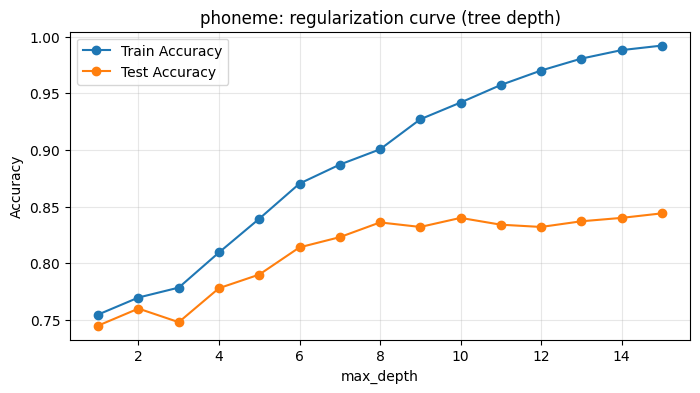

In [80]:
openml_tree_diagnostics("phoneme")

#### banknote-authentication

Dataset: banknote-authentication
Task: classification
Best depth: 7
Best test Accuracy: 0.9818


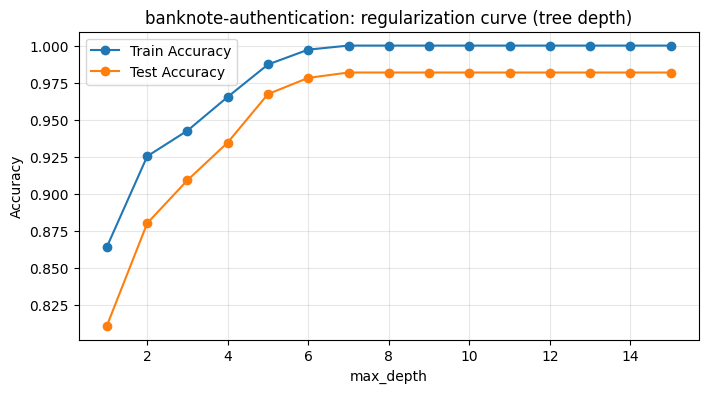

In [81]:
openml_tree_diagnostics("banknote-authentication")

#### delta_ailerons

Dataset: delta_ailerons
Task: classification
Best depth: 4
Best test Accuracy: 0.9370


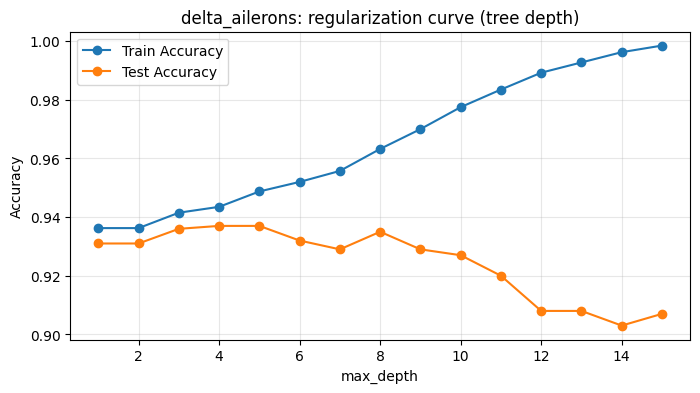

In [82]:
openml_tree_diagnostics("delta_ailerons")

#### mammography

Dataset: mammography
Task: classification
Best depth: 6
Best test Accuracy: 0.9840


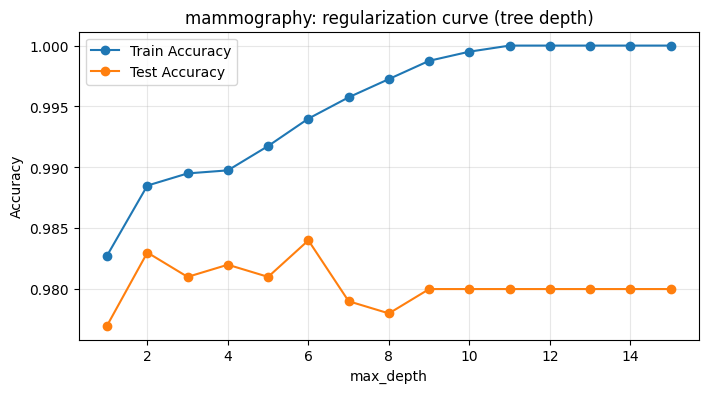

In [83]:
openml_tree_diagnostics("mammography")

#### electricity

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name electricity exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=151
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43945

  warn(warning_msg)


Dataset: electricity
Task: classification
Best depth: 14
Best test Accuracy: 0.7840


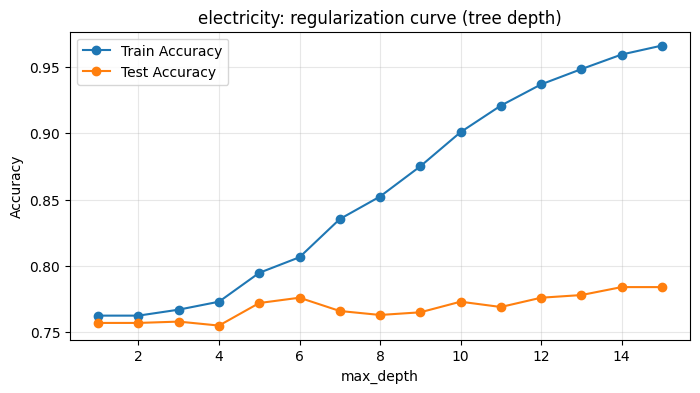

In [84]:
openml_tree_diagnostics("electricity")

#### mozilla4

Dataset: mozilla4
Task: classification
Best depth: 7
Best test Accuracy: 0.9360


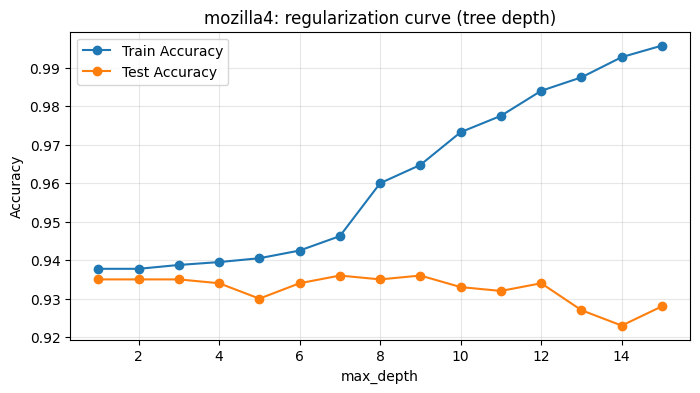

In [85]:
openml_tree_diagnostics("mozilla4")

#### kropt

Dataset: kropt
Task: classification
Best depth: 15
Best test Accuracy: 0.5540


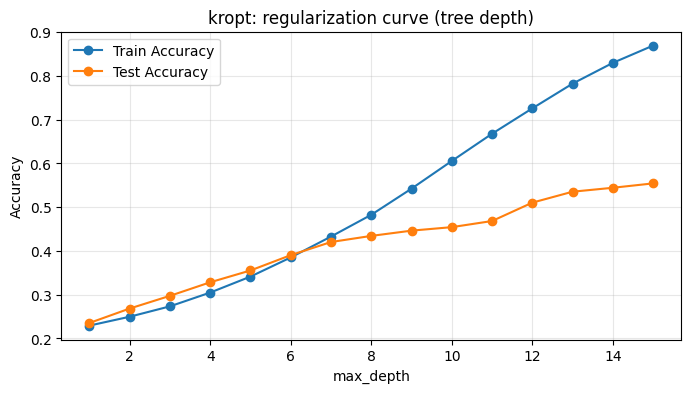

In [86]:
openml_tree_diagnostics("kropt")

#### nursery

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)


Dataset: nursery
Task: classification
Best depth: 12
Best test Accuracy: 0.9810


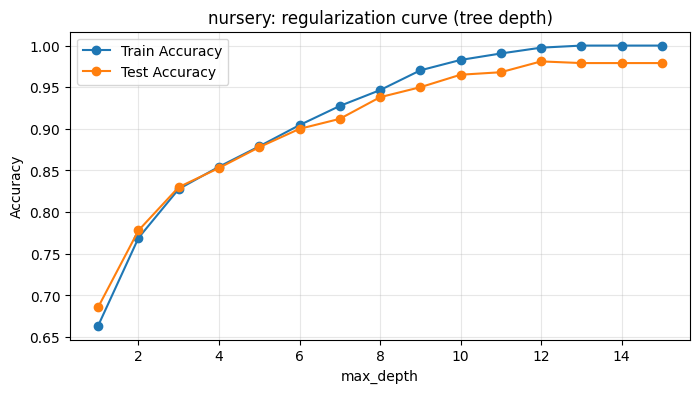

In [87]:
openml_tree_diagnostics("nursery")

#### volcanoes-b3

Dataset: volcanoes-b3
Task: classification
Best depth: 1
Best test Accuracy: 0.9680


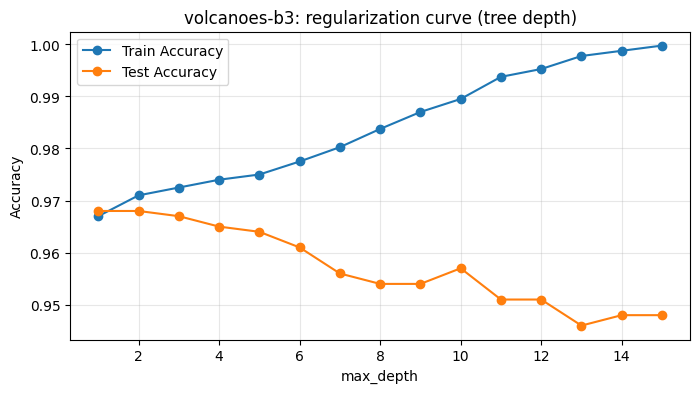

In [88]:
openml_tree_diagnostics("volcanoes-b3")

#### Дополнительные задания

#### 1. Повторите анализ последнего примера но с другими разделениями датасета на обучающую и тестовую выборки (изменяйте параметр random_state). Как меняется вид графиков?

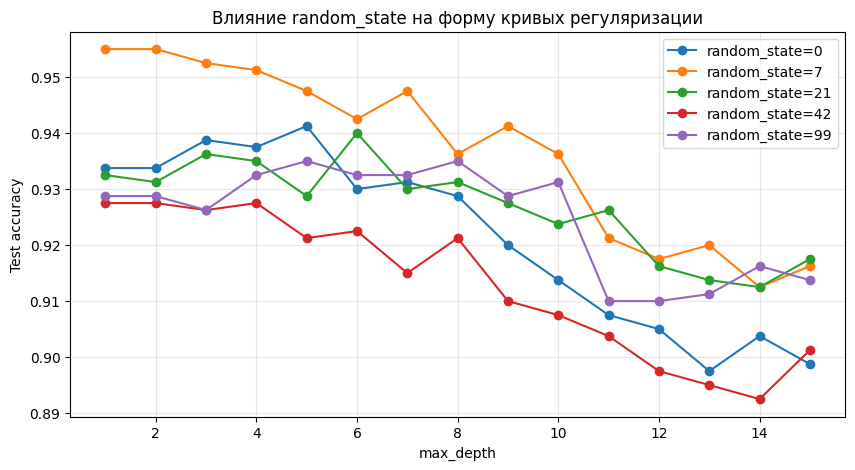

In [90]:
random_states = [0, 7, 21, 42, 99]
depths = range(1, 16)

plt.figure(figsize=(10, 5))
for rs in random_states:
    data = fetch_openml(name="delta_ailerons", parser="auto", as_frame=True)
    X_rs = pd.get_dummies(data.data)
    y_rs = data.target.astype(str)

    sampled_idx = X_rs.sample(min(4000, len(X_rs)), random_state=rs).index
    X_rs = X_rs.loc[sampled_idx]
    y_rs = y_rs.loc[sampled_idx]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_rs, y_rs, test_size=0.2, random_state=rs
    )

    test_curve = []
    for depth_value in depths:
        model_rs = DecisionTreeClassifier(max_depth=depth_value, random_state=rs)
        model_rs.fit(X_tr, y_tr)
        test_curve.append(accuracy_score(y_te, model_rs.predict(X_te)))

    plt.plot(list(depths), test_curve, marker="o", label=f"random_state={rs}")

plt.xlabel("max_depth")
plt.ylabel("Test accuracy")
plt.title("Влияние random_state на форму кривых регуляризации")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### 2. Напишите код построения кривых регуляризации, использующий кросс-валидацию.

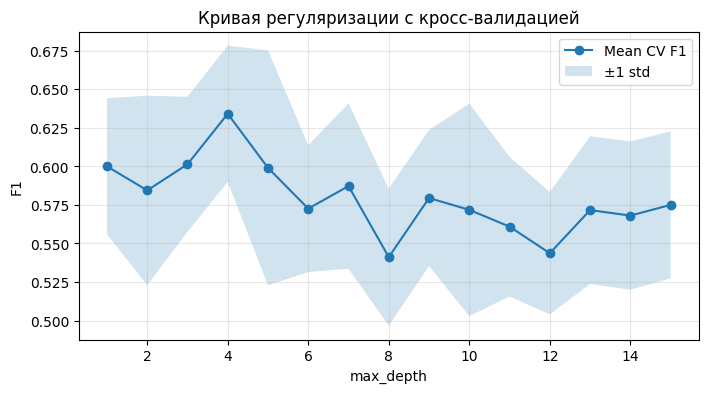

Best depth by CV F1: 4
Best mean CV F1: 0.6341


In [91]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

df_cv = pd.read_csv("data/diabetes.csv")
X_cv = df_cv.drop("Outcome", axis=1)
y_cv = df_cv["Outcome"]

depth_values = range(1, 16)
f1_cv_mean = []
f1_cv_std = []

for depth_value in depth_values:
    cv_model = DecisionTreeClassifier(max_depth=depth_value, random_state=42)
    scores = cross_val_score(
        cv_model,
        X_cv,
        y_cv,
        scoring="f1",
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    )
    f1_cv_mean.append(scores.mean())
    f1_cv_std.append(scores.std())

plt.figure(figsize=(8, 4))
plt.plot(list(depth_values), f1_cv_mean, marker="o", label="Mean CV F1")
plt.fill_between(
    list(depth_values),
    np.array(f1_cv_mean) - np.array(f1_cv_std),
    np.array(f1_cv_mean) + np.array(f1_cv_std),
    alpha=0.2,
    label="±1 std"
 )
plt.xlabel("max_depth")
plt.ylabel("F1")
plt.title("Кривая регуляризации с кросс-валидацией")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

best_depth_cv = list(depth_values)[int(np.argmax(f1_cv_mean))]
print(f"Best depth by CV F1: {best_depth_cv}")
print(f"Best mean CV F1: {max(f1_cv_mean):.4f}")